In [31]:
# Instalação de dependências!pip install shap xgboost scikit-learn pandas numpy matplotlib --quiet

In [32]:
# Importsimport numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
import shap

print("Bibliotecas carregadas com sucesso.")
print(f"  shap      {shap.__version__}")

Bibliotecas carregadas com sucesso.
  shap      0.51.0


In [33]:
# Carregamento e limpeza dos dados

df = pd.read_csv("cardio_train.csv", sep=";")  # separador padrão do dataset

# Limpeza: pressão arterial
df = df[
    (df["ap_hi"].between(70, 250)) &
    (df["ap_lo"].between(40, 150)) &
    (df["ap_hi"] > df["ap_lo"])
].copy()

# Altura e peso
df = df[
    (df["height"].between(120, 220)) &
    (df["weight"].between(40, 200))
].copy()

# Engenharia de atributos
df["age_years"] = df["age"] / 365.25
df["imc"] = df["weight"] / ((df["height"] / 100) ** 2)
df = df[df["imc"].between(15, 60)].copy()

print(f"N após limpeza: {df.shape[0]:,} observações")

N após limpeza: 68,533 observações


In [34]:
# Definição de variáveis e particionamento

features = [
    "age_years", "gender", "imc",
    "ap_hi", "ap_lo",
    "cholesterol", "gluc",
    "smoke", "alco", "active"
]
target = "cardio"

X = df[features]
y = df[target].astype(int)

# Particionamento estratificado (75% treino / 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")
print(f"Prevalência (teste): {y_test.mean():.3f}")

Treino: 51,399 | Teste: 17,134
Prevalência (teste): 0.495


In [35]:
# Treinamento do modelo XGBoost

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Treinamento concluído.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:11:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Treinamento concluído.


In [36]:
# Avaliação preditiva

y_prob = model.predict_proba(X_test)[:, 1]

auc   = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print(f"AUC-ROC    : {auc:.4f}")
print(f"Brier Score: {brier:.4f}")


AUC-ROC    : 0.8015
Brier Score: 0.1800


In [37]:
# Cálculo dos valores SHAP (TreeSHAP)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
base_value  = explainer.expected_value

print(f"Valor base φ₀: {base_value:.4f}  (escala log-odds)")

# Verificação da decomposição aditiva para a primeira observação
i = 0
pred_logodds      = base_value + shap_values[i].sum()
pred_prob_check   = 1 / (1 + np.exp(-pred_logodds))
print(f"\nVerificação (observação {i}):")
print(f"  Predição reconstruída via SHAP : {pred_prob_check:.4f}")
print(f"  Predição direta do modelo      : {y_prob[i]:.4f}")


Valor base φ₀: -0.0199  (escala log-odds)

Verificação (observação 0):
  Predição reconstruída via SHAP : 0.5615
  Predição direta do modelo      : 0.5615


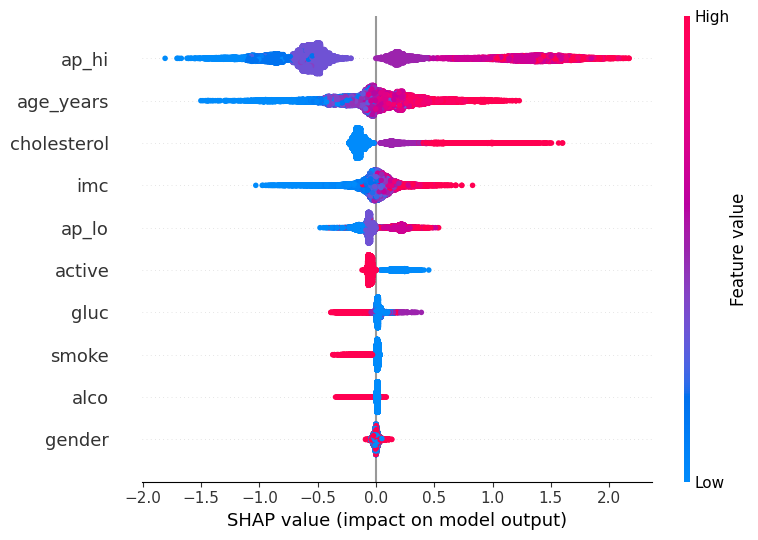

In [38]:
# Summary plot (beeswarm): importância global + direção dos efeitos

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    feature_names=features,
    show=True
)

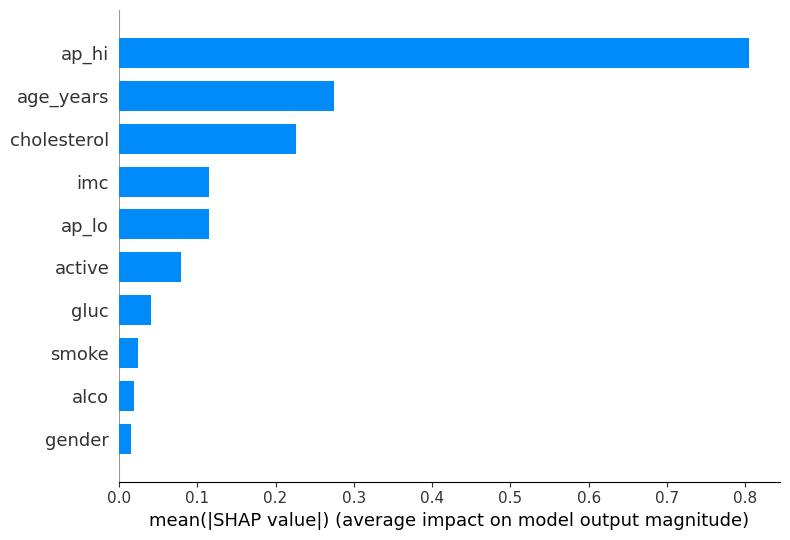

In [39]:
# Bar plot: ranking de importância global

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=features,
    show=True
)

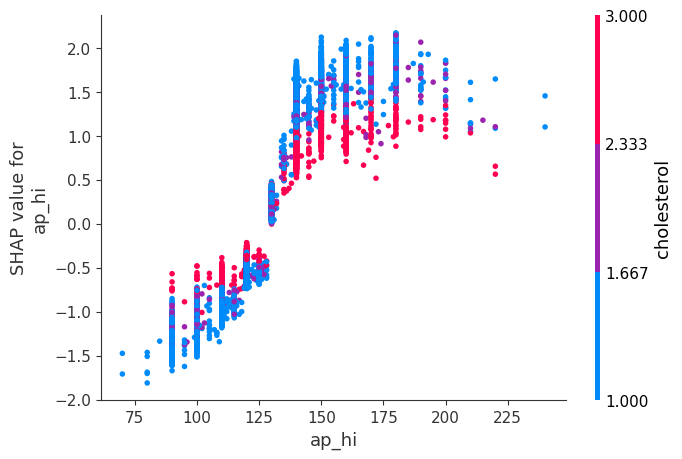

In [40]:
# Dependence plot: ap_hi × colesterol

shap.dependence_plot(
    "ap_hi",
    shap_values,
    X_test,
    interaction_index="cholesterol",
    feature_names=features,
    show=True
)

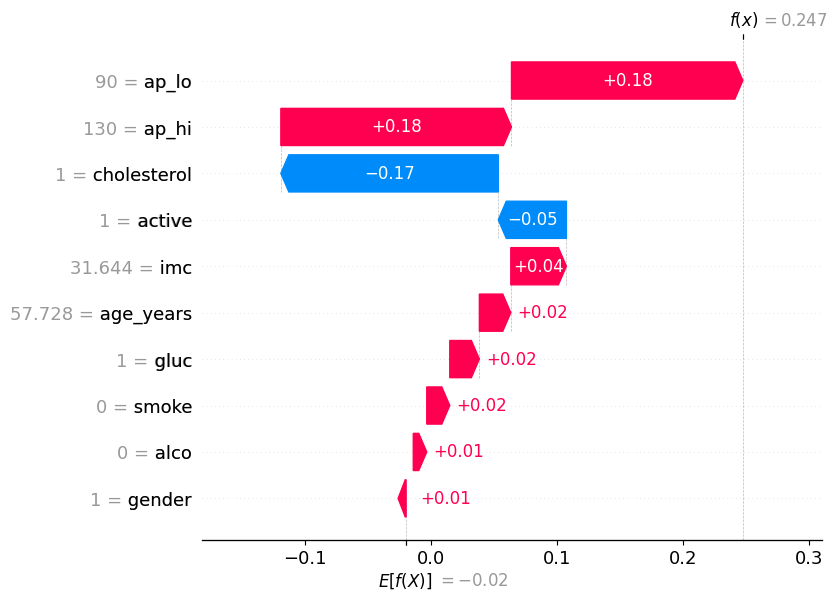


Decomposição SHAP — Paciente 0:
  Valor base φ₀ : -0.0199
  Predição final: 0.2475 (log-odds) → 0.5615 (probabilidade)

   Variável  Valor observado  Contribuição SHAP (log-odds)
      ap_lo        90.000000                      0.183679
      ap_hi       130.000000                      0.183068
cholesterol         1.000000                     -0.172611
     active         1.000000                     -0.054070
        imc        31.644318                      0.044140
  age_years        57.727584                      0.024953
       gluc         1.000000                      0.023479
      smoke         0.000000                      0.018281
       alco         0.000000                      0.010708
     gender         1.000000                      0.005685


In [41]:
# Waterfall plot: explicação local para um paciente específico

idx_paciente = 0  # altere para inspecionar outro paciente

# Garantir tipo escalar para base_value (compatibilidade entre versões do shap)
bv = float(np.array(base_value).reshape(-1)[0]) \
     if isinstance(base_value, (list, tuple, np.ndarray)) \
     else float(base_value)

exp = shap.Explanation(
    values      = np.array(shap_values)[idx_paciente],
    base_values = bv,
    data        = X_test.iloc[idx_paciente].to_numpy(),
    feature_names = features
)

shap.plots.waterfall(exp)

# Exibir contribuições em tabela
contrib_df = pd.DataFrame({
    "Variável"       : features,
    "Valor observado": X_test.iloc[idx_paciente].values,
    "Contribuição SHAP (log-odds)": shap_values[idx_paciente]
}).sort_values("Contribuição SHAP (log-odds)", key=abs, ascending=False)

print(f"\nDecomposição SHAP — Paciente {idx_paciente}:")
print(f"  Valor base φ₀ : {bv:.4f}")
print(f"  Predição final: {pred_logodds:.4f} (log-odds) "
      f"→ {pred_prob_check:.4f} (probabilidade)")
print()
print(contrib_df.to_string(index=False))


In [42]:
# CÉLULA 13 — Force plot: visualização compacta da explicação local

shap.initjs()
shap.force_plot(
    bv,
    shap_values[idx_paciente],
    X_test.iloc[idx_paciente],
    feature_names=features
)


In [43]:
# Importância global: tabela ordenada por |SHAP médio|

mean_abs_shap = pd.DataFrame({
    "Variável"         : features,
    "Importância global (E[|φᵢ|])": np.abs(shap_values).mean(axis=0)
}).sort_values("Importância global (E[|φᵢ|])", ascending=False)

print("Ranking de importância global:")
print(mean_abs_shap.to_string(index=False))


Ranking de importância global:
   Variável  Importância global (E[|φᵢ|])
      ap_hi                      0.804234
  age_years                      0.274260
cholesterol                      0.225658
        imc                      0.114973
      ap_lo                      0.114883
     active                      0.079151
       gluc                      0.041233
      smoke                      0.024697
       alco                      0.019488
     gender                      0.015031
